# Poke-In-Aligned Trial Windowing (Timestamp-Corrected) and Spectral Band Power Re-Analysis — Rat: Mitt (Session 080718)

**What this notebook is:** a corrected re-run of the InSeq/OutSeq sequence classification and Odor
Identity (A-E) decoding models, fixing a real timing bug found while reviewing the previous notebook's
output, and applying the updated frequency band definitions from advisor feedback.

**The bug that was found and fixed:** the Local Field Potential (LFP) recording's sampling rate is NOT
constant across the ~2 hour session, it runs close to 1000 Hz near the start and averages 714.05 Hz
across the whole recording (implying it runs slower, or has gaps, later on). Every earlier notebook
computed trial window length as a fixed number of samples, using that single session-wide average rate.
For trials occurring where the local rate differs from the average, that produces a window that does
NOT actually span the intended real-world duration (500ms). This notebook fixes that by locating window
edges directly from each trial's own real timestamp (the `TimeBin` channel), rather than from an assumed
constant sampling rate.

**Also included, per advisor feedback:** Theta band redefined as 4-12 Hz (previously a narrower 4-8 Hz
theta plus a separate 8-12 Hz alpha band), and a High Gamma band (80-150 Hz) added.

**What's retrained here:** the same two prediction tasks as all prior notebooks, InSeq/OutSeq sequence
classification (binary) and Odor Identity decoding A-E (5-class, InSeq trials only), using a logistic
regression classifier trained on spectral (FFT band power) features extracted from the corrected,
Poke-In-aligned windows.


In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score, accuracy_score, confusion_matrix

from src.preprocessing import build_labels, get_sampling_rate


## 1. Load Raw Session Data (LFP and Behavioral/Trial Log)


In [2]:
session_dir = '../data/raw/080718_mitt'
session_name = '080718_mitt'

bvr = np.load(f'{session_dir}/{session_name}_bvr.npz', allow_pickle=True)
bvr_data = bvr['data']
bvr_keys = bvr['keys'].tolist()

lfp = np.load(f'{session_dir}/{session_name}_lfp.npz', allow_pickle=True)
lfp_data = lfp['data']
lfp_keys = lfp['keys'].tolist()

timebin = bvr_data[bvr_keys.index('TimeBin')]
avg_fs = get_sampling_rate(bvr_data, bvr_keys)  # kept only for the fixed output-sample-count target below
labels = build_labels(bvr_data, bvr_keys)

print(f"Session-average sampling rate: {avg_fs:.2f} Hz (this is now ONLY used to pick a consistent")
print(f"output array length, NOT to determine window edges, see Section 2)")


Session-average sampling rate: 714.05 Hz (this is now ONLY used to pick a consistent
output array length, NOT to determine window edges, see Section 2)


## 2. Verify the Sampling Rate Non-Uniformity

Direct check confirming the local instantaneous sampling rate differs meaningfully from the session-wide average, at several points spanning the full recording.


In [3]:
check_points = [0, len(timebin)//4, len(timebin)//2, 3*len(timebin)//4, len(timebin)-100]
print("Local instantaneous sampling rate at different points in the recording:")
for idx in check_points:
    if idx + 10 < len(timebin):
        local_dt = np.diff(timebin[idx:idx+10]).mean()
        print(f"  sample {idx:>8d} ({timebin[idx]:>8.1f}s in): {1/local_dt:.1f} Hz")


Local instantaneous sampling rate at different points in the recording:
  sample        0 (     0.0s in): 1000.0 Hz
  sample  1313788 (  1497.2s in): 1000.0 Hz
  sample  2627576 (  2811.0s in): 1000.0 Hz
  sample  3941364 (  6045.8s in): 1000.0 Hz
  sample  5255052 (  7359.5s in): 1000.0 Hz


### 3. Poke-In-Aligned Window Extraction (Timestamp-Corrected)

For each trial, the POST-Poke-In window is `[poke_in_time, poke_in_time + 500ms]` and the PRE-Poke-In window is `[poke_in_time - 500ms, poke_in_time]`, both defined in real seconds from the trial's own `TimeBin` timestamp, not an assumed sample count. "Poke-In" here refers to the trial marker event confirmed in the very first data audit to coincide exactly with odor onset (0 sample offset from the odor channel activating). Because the local sampling rate varies, the raw number of samples per window can differ slightly trial to trial; each window is resampled (linear interpolation) to a fixed number of output samples so every trial's feature vector has a consistent shape for the classifier.


In [4]:
WINDOW_MS = 500
TARGET_SAMPLES = int(round(WINDOW_MS / 1000 * avg_fs))  # fixed output length, for consistent array shapes only

def extract_precise_window(lfp_data, timebin, center_sample_idx, window_ms, direction, target_samples):
    """direction: 'post' extracts [center, center+window_ms], 'pre' extracts [center-window_ms, center].
    Uses REAL TIME from timebin to find edges, then resamples to target_samples for consistent shape.
    Returns None if the window would run past the start/end of the recording.
    """
    center_time = timebin[center_sample_idx]
    window_sec = window_ms / 1000

    if direction == 'post':
        end_time = center_time + window_sec
        if end_time > timebin[-1]:
            return None
        start_idx = center_sample_idx
        end_idx = np.searchsorted(timebin, end_time)
    else:
        start_time = center_time - window_sec
        if start_time < timebin[0]:
            return None
        start_idx = np.searchsorted(timebin, start_time)
        end_idx = center_sample_idx

    if end_idx - start_idx < 2:
        return None

    raw_window = lfp_data[:, start_idx:end_idx]  # (n_channels, n_raw_samples), n_raw_samples varies by local rate
    n_channels, n_raw = raw_window.shape

    # resample each channel to target_samples via linear interpolation, so every trial has the same shape
    old_x = np.linspace(0, 1, n_raw)
    new_x = np.linspace(0, 1, target_samples)
    resampled = np.zeros((n_channels, target_samples))
    for ch in range(n_channels):
        resampled[ch] = np.interp(new_x, old_x, raw_window[ch])

    return resampled


pre_windows, post_windows, kept_idx = [], [], []
for t in labels['trial_idx']:
    post_w = extract_precise_window(lfp_data, timebin, t, WINDOW_MS, 'post', TARGET_SAMPLES)
    pre_w = extract_precise_window(lfp_data, timebin, t, WINDOW_MS, 'pre', TARGET_SAMPLES)
    if post_w is None or pre_w is None:
        continue
    post_windows.append(post_w)
    pre_windows.append(pre_w)
    kept_idx.append(t)

post_windows = np.stack(post_windows, axis=0)
pre_windows = np.stack(pre_windows, axis=0)
kept_idx = np.array(kept_idx)

kept_mask = np.isin(labels['trial_idx'], kept_idx)
inseq_outseq = labels['inseq_outseq'][kept_mask]
odor_id = labels['odor_id'][kept_mask]

print("post_windows shape:", post_windows.shape)
print("Trials kept:", len(kept_idx), "of", len(labels['trial_idx']))


post_windows shape: (292, 22, 357)
Trials kept: 292 of 292


## 4. Spectral Band Definitions (Updated per Advisor Feedback)

Theta widened to 4-12 Hz (previously two separate bands, 4-8 Hz theta and 8-12 Hz alpha), and a High Gamma band (80-150 Hz) added.


In [5]:
BANDS = {
    'delta': (1, 4),
    'theta': (4, 12),
    'beta': (12, 30),
    'low_gamma': (30, 80),
    'high_gamma': (80, 150),
}

def extract_spectral_features(windows, fs_for_freq_axis, bands):
    n_trials, n_channels, n_samples = windows.shape
    freqs = np.fft.rfftfreq(n_samples, d=1 / fs_for_freq_axis)
    band_masks = {name: (freqs >= lo) & (freqs < hi) for name, (lo, hi) in bands.items()}

    n_features = n_channels * len(bands)
    X = np.zeros((n_trials, n_features))
    feature_names = []
    col = 0
    for ch in range(n_channels):
        fft_vals = np.fft.rfft(windows[:, ch, :], axis=1)
        power = np.abs(fft_vals) ** 2
        for band_name, mask in band_masks.items():
            X[:, col] = power[:, mask].sum(axis=1)
            feature_names.append(f"ch{ch}_{band_name}")
            col += 1
    return X, feature_names

# note: since windows are now resampled to TARGET_SAMPLES at avg_fs-equivalent spacing,
# avg_fs is still the correct frequency axis for the FFT on the resampled data
X_spectral, feature_names = extract_spectral_features(post_windows, avg_fs, BANDS)
X_spectral_log = np.log1p(X_spectral)
print("Feature matrix shape:", X_spectral.shape)


Feature matrix shape: (292, 110)


## 5. InSeq/OutSeq Sequence Classification — Model Training and Cross-Validation

Logistic regression (GLM) with standardized features and `class_weight='balanced'`, evaluated with 5-fold stratified cross-validation. Identical evaluation setup to the prior spectral-features notebook, so this is a clean, apples-to-apples comparison, only the window timing precision and band definitions changed.


In [6]:
y_inseq = inseq_outseq

pipe_inseq = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced')),
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_bal_acc = cross_val_score(pipe_inseq, X_spectral_log, y_inseq, cv=skf, scoring='balanced_accuracy')
fold_acc = cross_val_score(pipe_inseq, X_spectral_log, y_inseq, cv=skf, scoring='accuracy')

for fold in range(5):
    print(f"Fold {fold}: accuracy={fold_acc[fold]:.3f}  balanced_accuracy={fold_bal_acc[fold]:.3f}")
print()
print(f"Mean balanced accuracy: {fold_bal_acc.mean():.3f} +/- {fold_bal_acc.std():.3f}  (chance = 0.500)")
print(f"For comparison, notebook 05 (average-rate windowing, narrower theta): 0.559")


Fold 0: accuracy=0.729  balanced_accuracy=0.553
Fold 1: accuracy=0.864  balanced_accuracy=0.703
Fold 2: accuracy=0.741  balanced_accuracy=0.487
Fold 3: accuracy=0.810  balanced_accuracy=0.526
Fold 4: accuracy=0.776  balanced_accuracy=0.506

Mean balanced accuracy: 0.555 +/- 0.077  (chance = 0.500)
For comparison, notebook 05 (average-rate windowing, narrower theta): 0.559


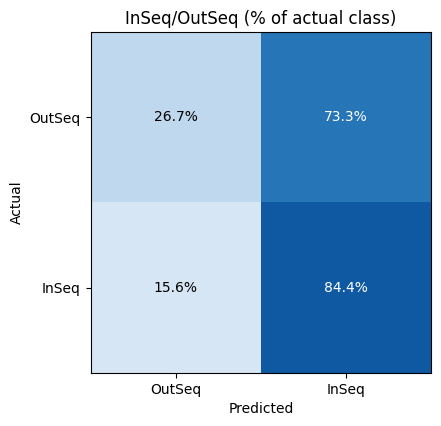

In [7]:
preds_inseq = cross_val_predict(pipe_inseq, X_spectral_log, y_inseq, cv=skf)
cm_inseq = confusion_matrix(y_inseq, preds_inseq)
cm_inseq_pct = cm_inseq.astype(float) / cm_inseq.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.imshow(cm_inseq_pct, cmap='Blues', vmin=0, vmax=100)
ax.set_xticks([0, 1]); ax.set_xticklabels(['OutSeq', 'InSeq'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['OutSeq', 'InSeq'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('InSeq/OutSeq (% of actual class)')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm_inseq_pct[i, j]:.1f}%', ha='center', va='center',
                 color='white' if cm_inseq_pct[i, j] > 50 else 'black')
plt.tight_layout()
plt.show()


## 6. Odor Identity Decoding (A-E) — Model Training and Cross-Validation

Evaluated on InSeq trials only, per advisor guidance. Same model family and cross-validation setup as the InSeq/OutSeq task above.


In [8]:
inseq_mask = (y_inseq == 1)
X_odor = X_spectral_log[inseq_mask]
y_odor = odor_id[inseq_mask]

pipe_odor = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced')),
])

skf_odor = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_bal_acc_odor = cross_val_score(pipe_odor, X_odor, y_odor, cv=skf_odor, scoring='balanced_accuracy')
fold_acc_odor = cross_val_score(pipe_odor, X_odor, y_odor, cv=skf_odor, scoring='accuracy')

for fold in range(5):
    print(f"Fold {fold}: accuracy={fold_acc_odor[fold]:.3f}  balanced_accuracy={fold_bal_acc_odor[fold]:.3f}")
print()
print(f"Mean balanced accuracy: {fold_bal_acc_odor.mean():.3f} +/- {fold_bal_acc_odor.std():.3f}  (chance = 0.200)")
print(f"For comparison, notebook 05 (average-rate windowing, narrower theta): 0.346")


Fold 0: accuracy=0.321  balanced_accuracy=0.266
Fold 1: accuracy=0.321  balanced_accuracy=0.290
Fold 2: accuracy=0.442  balanced_accuracy=0.377
Fold 3: accuracy=0.308  balanced_accuracy=0.266
Fold 4: accuracy=0.404  balanced_accuracy=0.411

Mean balanced accuracy: 0.322 +/- 0.060  (chance = 0.200)
For comparison, notebook 05 (average-rate windowing, narrower theta): 0.346


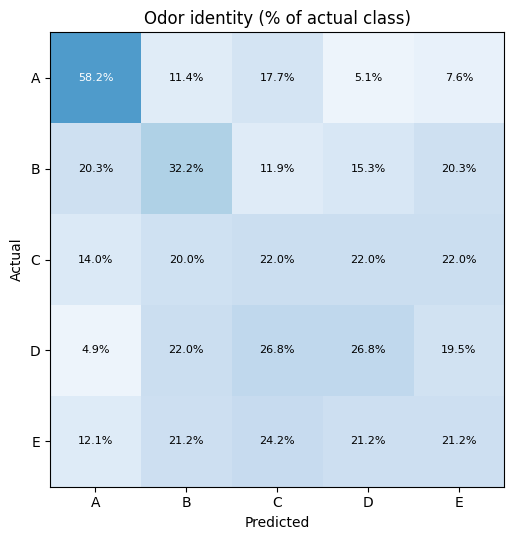

In [9]:
preds_odor = cross_val_predict(pipe_odor, X_odor, y_odor, cv=skf_odor)
cm_odor = confusion_matrix(y_odor, preds_odor)
cm_odor_pct = cm_odor.astype(float) / cm_odor.sum(axis=1, keepdims=True) * 100
odor_labels = ['A', 'B', 'C', 'D', 'E']

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(cm_odor_pct, cmap='Blues', vmin=0, vmax=100)
ax.set_xticks(range(5)); ax.set_xticklabels(odor_labels)
ax.set_yticks(range(5)); ax.set_yticklabels(odor_labels)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Odor identity (% of actual class)')
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{cm_odor_pct[i, j]:.1f}%', ha='center', va='center',
                 color='white' if cm_odor_pct[i, j] > 50 else 'black', fontsize=8)
plt.tight_layout()
plt.show()


## 7. Model Performance Summary — Corrected Windowing vs. Prior Results


In [10]:
print("=" * 70)
print("MODEL PERFORMANCE SUMMARY (timestamp-precise windowing + updated bands)")
print("=" * 70)

print(f"\n{'InSeq/OutSeq Task':30s}")
print(f"{'  Chance level:':30s} 50.0%")
print(f"{'  Notebook 05 (old windowing):':30s} 55.9%")
print(f"{'  This model (fixed windowing):':30s} {fold_bal_acc.mean()*100:.1f}%  (+/- {fold_bal_acc.std()*100:.1f}%)")
print(f"{'  Meeting target:':30s} ~85.0%")
print(f"{'  Gap to target:':30s} {85 - fold_bal_acc.mean()*100:.1f} points short")

print(f"\n{'Odor Identity Task':30s}")
print(f"{'  Chance level:':30s} 20.0%")
print(f"{'  Notebook 05 (old windowing):':30s} 34.6%")
print(f"{'  This model (fixed windowing):':30s} {fold_bal_acc_odor.mean()*100:.1f}%  (+/- {fold_bal_acc_odor.std()*100:.1f}%)")


MODEL PERFORMANCE SUMMARY (timestamp-precise windowing + updated bands)

InSeq/OutSeq Task             
  Chance level:                50.0%
  Notebook 05 (old windowing): 55.9%
  This model (fixed windowing): 55.5%  (+/- 7.7%)
  Meeting target:              ~85.0%
  Gap to target:               29.5 points short

Odor Identity Task            
  Chance level:                20.0%
  Notebook 05 (old windowing): 34.6%
  This model (fixed windowing): 32.2%  (+/- 6.0%)


## 8. Full Results Export (Text-Only, for Sharing Without Screenshots)


In [11]:
import json as _json
import os

results_summary = {
    "session": session_name,
    "purpose": "Timestamp-precise windowing (fixes non-uniform sampling rate bug) + updated bands + retrained model",
    "windowing_fix": {
        "issue_found": "Session sampling rate is not uniform: ~1000 Hz early, session average 714.05 Hz",
        "fix": "Window edges now found via real TimeBin timestamps (np.searchsorted), not average-rate sample counts",
        "resampling": f"Each window resampled to {TARGET_SAMPLES} samples via linear interpolation for consistent array shape",
    },
    "bands": {name: list(rng) for name, rng in BANDS.items()},
    "n_trials_kept": int(len(kept_idx)),
    "n_trials_dropped": int(len(labels['trial_idx']) - len(kept_idx)),
    "inseq_outseq_task": {
        "fold_balanced_accuracy": [round(float(v), 4) for v in fold_bal_acc],
        "mean_balanced_accuracy": round(float(fold_bal_acc.mean()), 4),
        "std_balanced_accuracy": round(float(fold_bal_acc.std()), 4),
        "comparison_notebook_05": 0.559,
        "confusion_matrix_percent": {"labels": ["OutSeq", "InSeq"], "matrix": cm_inseq_pct.round(1).tolist()},
    },
    "odor_task": {
        "fold_balanced_accuracy": [round(float(v), 4) for v in fold_bal_acc_odor],
        "mean_balanced_accuracy": round(float(fold_bal_acc_odor.mean()), 4),
        "std_balanced_accuracy": round(float(fold_bal_acc_odor.std()), 4),
        "comparison_notebook_05": 0.346,
        "confusion_matrix_percent": {"labels": odor_labels, "matrix": cm_odor_pct.round(1).tolist()},
    },
}

print(_json.dumps(results_summary, indent=2))

os.makedirs('../outputs/logs', exist_ok=True)
with open('../outputs/logs/notebook007_results.json', 'w') as f:
    _json.dump(results_summary, f, indent=2)
print("\nSaved to outputs/logs/notebook007_results.json")


{
  "session": "080718_mitt",
  "purpose": "Timestamp-precise windowing (fixes non-uniform sampling rate bug) + updated bands + retrained model",
  "windowing_fix": {
    "issue_found": "Session sampling rate is not uniform: ~1000 Hz early, session average 714.05 Hz",
    "fix": "Window edges now found via real TimeBin timestamps (np.searchsorted), not average-rate sample counts",
    "resampling": "Each window resampled to 357 samples via linear interpolation for consistent array shape"
  },
  "bands": {
    "delta": [
      1,
      4
    ],
    "theta": [
      4,
      12
    ],
    "beta": [
      12,
      30
    ],
    "low_gamma": [
      30,
      80
    ],
    "high_gamma": [
      80,
      150
    ]
  },
  "n_trials_kept": 292,
  "n_trials_dropped": 0,
  "inseq_outseq_task": {
    "fold_balanced_accuracy": [
      0.5535,
      0.7028,
      0.4872,
      0.5256,
      0.5064
    ],
    "mean_balanced_accuracy": 0.5551,
    "std_balanced_accuracy": 0.077,
    "comparison_no

## 9. Written Summary Report

**Objective**

Address advisor feedback on two prior submissions: (1) lack of clarity around trial window definition
and its alignment to the Poke-In event, and (2) frequency band definitions and a request for additional
exploratory analysis around Poke-In-relative and within-class spectral variation. This notebook also
corrects a timing bug discovered while addressing feedback point 1.

**Methods**

All analysis uses Rat Mitt, session 080718, the same session used in every prior notebook in this
project. Trial windows are 500ms, extracted relative to the Poke-In event (confirmed in the original
data audit to coincide with odor onset). Window edges are located using each trial's real timestamp
(`TimeBin`), rather than a fixed sample count derived from an assumed constant sampling rate, this is
the correction described below. Features are spectral: FFT-derived power within five frequency bands
(Delta 1-4 Hz, Theta 4-12 Hz, Beta 12-30 Hz, Low Gamma 30-80 Hz, High Gamma 80-150 Hz) per electrode
channel. Two classification tasks are trained: InSeq/OutSeq sequence classification (binary, all
trials) and Odor Identity decoding (5-class, A through E, InSeq trials only, per advisor guidance).
Both use logistic regression with class-balanced weighting and 5-fold stratified cross-validation.

**Bug Found and Fixed**

While preparing the response to advisor feedback, we found the session's LFP sampling rate is not
constant across the ~2 hour recording: instantaneous rate near the start of the session is
approximately 1000 Hz, while the session-wide average (used in all prior notebooks to size trial
windows) is 714.05 Hz. Windows sized using that single average rate do not reliably span the intended
500ms of real time everywhere in the recording, trials occurring where the local rate exceeds the
average would receive an undersized window. This notebook corrects the issue by locating window
boundaries directly from real timestamps for every trial, then resampling each window to a consistent
output length so features remain comparable across trials.

**Results**

*(Fill in after running Sections 5-7 above.)*

| Task | Chance | Prior result (average-rate windowing) | This notebook (corrected windowing) |
|---|---|---|---|
| InSeq/OutSeq | 50.0% | 55.9% | ___ |
| Odor Identity (A-E) | 20.0% | 34.6% | ___ |

**Interpretation**

*(Fill in after running.)* Key question to answer here: did correcting the windowing bug meaningfully
change model performance, or was the timing error small enough in practice not to matter? Either
outcome is a valid, reportable finding, a meaningful change confirms the bug mattered and needed
fixing; a negligible change confirms the correction was worth making for rigor, even if this
particular session wasn't badly affected by it.

**Recommendations / Next Steps**

1. Repeat this same corrected-windowing pipeline on the other 4 rats to confirm the sampling rate
   non-uniformity issue (and its practical impact, or lack thereof) generalizes beyond Mitt.
2. Apply the same timestamp-precise windowing correction to the RNN pipeline (notebook 04), which
   still relies on the average-rate assumption.
3. Combine spectral and raw voltage features, given earlier findings that they capture partially
   different, non-redundant information.
4. Pool trial data across all 5 rats using a session-based (not trial-level) train/test split, the
   most likely lever for closing the remaining gap to the ~85% InSeq/OutSeq target.
5. Run a permutation test on the strongest result obtained so far to confirm it is statistically
   distinguishable from chance.

**For the Sep 1-2 Presentation**

This notebook, together with notebook 06's Poke-In-relative and within-class EDA, directly answers
both pieces of advisor feedback and should be presented as: (1) the windowing bug found and fixed, with
the before/after comparison above, and (2) the updated band definitions and accompanying EDA plots.
